In [1]:
import os
from pathlib import Path
import pandas as pd
import pysam
from icecream import ic
import numpy as np
from tqdm import tqdm

import sys
from pathlib import Path
# Add nuctool directory to path for imports
nuctool_path = Path.cwd().parent / 'nuctool'
if str(nuctool_path) not in sys.path:
    sys.path.insert(0, str(nuctool_path))
from Plotter import Plotter

from ChromatinFibers import (
    convert_to_footprints,
    fetch_chromosome_sequence,
    ChromatinFiber,
    compute_vanderlick,
)

from Plotter import Plotter, plot_sequence, plot_footprints
from pycorrelate import pcorrelate

plot = Plotter()
FILEOUT = rf"figures/SimulateYeastFibers.jpg"

# Create the directory if it doesn't exist
output_dir = os.path.dirname(FILEOUT)
if output_dir and not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"Created directory: {output_dir}")

In [2]:
filename = "occupancy_chrII"
occupancy = np.load(f"/home/mvenrooij/NucTool/nuctool/full_methylation_data_10000bp_interval/chrII/{filename}.npy")
# def extract_locus(locus_txt):
#     locus_txt = locus_txt.replace(',', '')
#     parts = locus_txt.split(':')
#     chrom = parts[0]
#     start, end = map(int, parts[1].split('-'))
#     return (chrom, start, end)

# locus = extract_locus(filename.lstrip("occupancy").rstrip(")"))
chrom, start, end = "chrII", 10000, 20000

In [3]:
chrom_number = chrom.lstrip("chr")

chromosome = fetch_chromosome_sequence(r".genomes/sacCer3/sacCer3.fa", chromosome=chrom_number)
length = end-start + 2000
#locus_start = np.random.randint(0, len(chromosome) - length)
locus_start = start - 1000
locus_end = locus_start + length
#locus_sequence = chromosome[-10001 : -1]
locus_sequence = chromosome[locus_start : locus_end]
fiber = ChromatinFiber(sequence=locus_sequence,start = locus_start)
fiber.fetch_orfs_by_range(start=locus_start, end=locus_end, chromosome=chrom_number)

Selected chromosome: .genomes/sacCer3, chrII  len=813184


In [19]:
from scipy.optimize import differential_evolution

def fit_lsq(y_data, physical_model_func, bounds):
    def objective(params):
        model_output = physical_model_func(*params)
        norm_factor = np.sqrt(np.sum(model_output ** 2)) / np.sqrt(np.sum(y_data ** 2))
        return np.sum((y_data - model_output) ** 2) / norm_factor

    res = differential_evolution(objective, bounds, strategy='best1bin', disp=True)
    return res.x

def model_func(period, amplitude, chemical_potential):
    fiber.calc_energy_landscape(
        octamer=True,
        period=period,
        amplitude=amplitude,
        chemical_potential=chemical_potential,
    )
    return fiber.occupancy[1000:-1000]

bounds = [
    (9.5, 10.5),    # period
    (0.01, 0.249),   # amplitude
    (0, 15),   # chemical_potential
]

period_lsq, amplitude_lsq, chemical_potential_lsq = fit_lsq(occupancy, model_func, bounds)

differential_evolution step 1: f(x)= 399.05336913055817
differential_evolution step 2: f(x)= 399.05336913055817
differential_evolution step 3: f(x)= 370.9186423721822
differential_evolution step 4: f(x)= 370.9186423721822
differential_evolution step 5: f(x)= 370.9186423721822
differential_evolution step 6: f(x)= 370.9186423721822
differential_evolution step 7: f(x)= 370.9186423721822
differential_evolution step 8: f(x)= 370.9186423721822
differential_evolution step 9: f(x)= 370.9186423721822
differential_evolution step 10: f(x)= 370.9186423721822
differential_evolution step 11: f(x)= 370.9186423721822
differential_evolution step 12: f(x)= 370.9186423721822
differential_evolution step 13: f(x)= 370.9186423721822
differential_evolution step 14: f(x)= 370.55872243524755
differential_evolution step 15: f(x)= 370.55872243524755
differential_evolution step 16: f(x)= 370.55872243524755
differential_evolution step 17: f(x)= 370.2120198313566
Polishing solution with 'L-BFGS-B'


In [20]:
print(f"LSQ fit → period={period_lsq:.4f}, amplitude={amplitude_lsq:.4f}, mu={chemical_potential_lsq:.4f}")

LSQ fit → period=9.5000, amplitude=0.0100, mu=4.5944


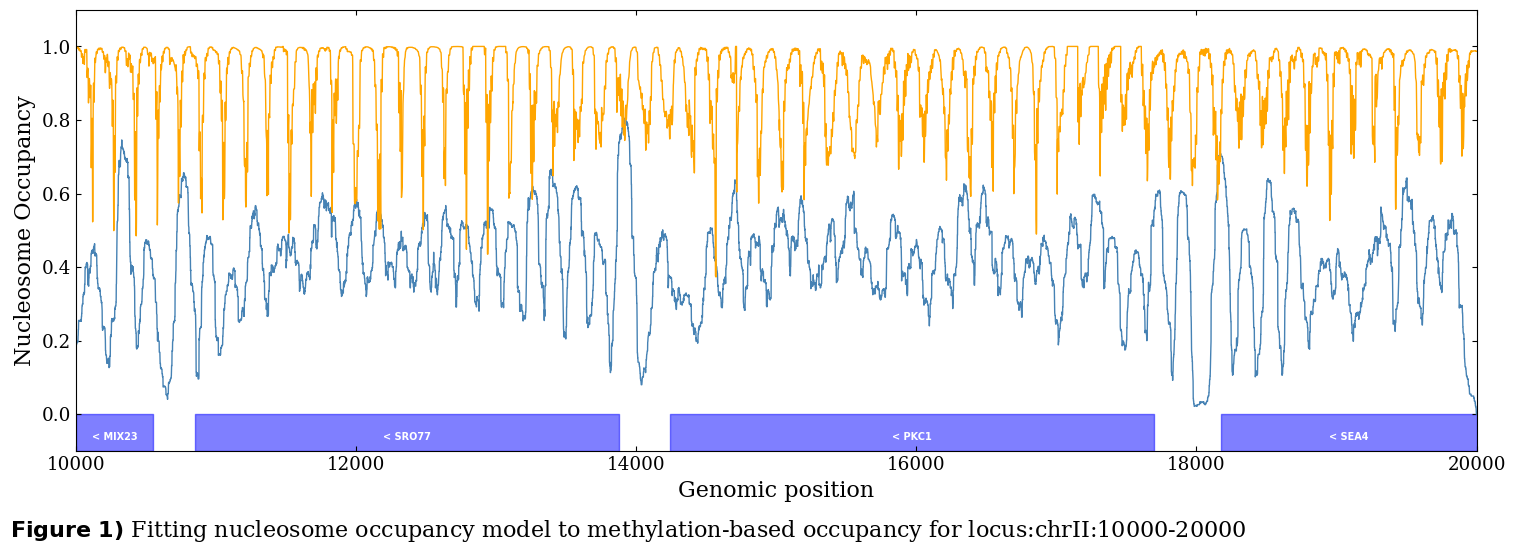

In [5]:
fiber.calc_energy_landscape(period=10, amplitude=0.0518, chemical_potential=-5)
lsq_occupancy = fiber.occupancy[1000:-1000]

x_coords = np.arange(start, end)
plotter = Plotter(fig_size=(15, 5))
plotter.new(ncols=1, nrows=1)

ax1 = plotter.axes
ax1.plot(x_coords, occupancy[start:end], label=f"Observed occupancy", color="steelblue",linewidth=1)
ax1.plot(x_coords, lsq_occupancy, label=f"Fitted occupancy, mu={6}, period={10}, amp={0.025}", color="orange", linewidth=1)
# ax1.plot(x_coords, lsq_occupancy, label=f"LSQ Fitted occupancy, mu={chemical_potential_lsq}, period={period_lsq}, amp={amplitude_lsq}", color="green", linewidth=1)
ax1.set_xlabel("Genomic position")
ax1.set_ylabel("Nucleosome Occupancy")

for orf in fiber.orfs:
            name = orf["name"]
            if orf["strand"] == -1:
                name = f"< {name}"
                top = 0
                bottom = -0.1
            else:
                name = f"{name} >"
                top = 0
                bottom = -0.1

            orf_start = min(orf["start"], orf["end"])
            orf_end = max(orf["start"], orf["end"])
            
            if orf_end < start or orf_start > end:
                continue

            # clip to visible range
            plot_start = max(orf_start, start)
            plot_end = min(orf_end, end)

            ax1.fill_between(
                [plot_start, plot_end],
                bottom,
                top,
                color="blue",
                alpha=0.5,
                label=orf["name"],
            )

            ax1.text(
                (plot_start + plot_end) / 2,
                -0.06,
                name,
                ha="center",
                va="center",
                fontsize=7,
                font='DejaVu Sans',
                weight="bold",
                color="white",
            )

ax1.set_xlim(start, end)
ax1.set_ylim(-0.1, 1.1)
plotter.caption(f"Fitting nucleosome occupancy model to methylation-based occupancy for locus:{chrom}:{start}-{end}")
# plt.legend()

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

def plot_correlation(measured, predicted, ax=None, title=None):
    """
    Scatter plot of predicted vs measured values with R² and Pearson r.

    Parameters
    ----------
    measured : array-like
        Observed/experimental occupancy.
    predicted : array-like
        Model output (e.g. from model_func with fitted parameters).
    ax : matplotlib Axes, optional
        Existing axis to draw into. If None, a new figure is created.
    title : str, optional
    """
    measured = np.asarray(measured).ravel()
    predicted = np.asarray(predicted).ravel()

    if measured.shape != predicted.shape:
        raise ValueError(
            f"Shape mismatch: measured {measured.shape} vs predicted {predicted.shape}"
        )

    # Statistics
    r, p_value = pearsonr(measured, predicted)
    r_squared = r ** 2
    rmse = np.sqrt(np.mean((predicted - measured) ** 2))

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))

    # Scatter
    ax.scatter(measured, predicted, s=8, alpha=0.4, edgecolor='none')

    # y = x reference line
    lo = min(measured.min(), predicted.min())
    hi = max(measured.max(), predicted.max())
    ax.plot([lo, hi], [lo, hi], 'k--', lw=1, label='y = x')

    # Linear fit line
    slope, intercept = np.polyfit(measured, predicted, 1)
    xs = np.array([lo, hi])
    ax.plot(xs, slope * xs + intercept, 'r-', lw=1.2,
            label=f'fit: y = {slope:.2f}x + {intercept:.2f}')

    ax.set_xlabel('Measured occupancy')
    ax.set_ylabel('Predicted occupancy')
    ax.set_title(title or 'Predicted vs. measured Least Squares Fit')
    ax.set_aspect('equal', adjustable='box')

    # Annotation box with stats
    stats_text = (
        f'$R^2$ = {r_squared:.3f}\n'
        f'r = {r:.3f}\n'
        f'RMSE = {rmse:.4f}\n'
        f'n = {len(measured)}'
    )
    ax.text(0.05, 0.95, stats_text, transform=ax.transAxes,
            va='top', ha='left',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.85))

    ax.legend(loc='lower right', fontsize=9)
    plt.tight_layout()
    return ax

plot_correlation(occupancy, lsq_occupancy)

ValueError: Shape mismatch: measured (813184,) vs predicted (10000,)

(0.0, 1.0)

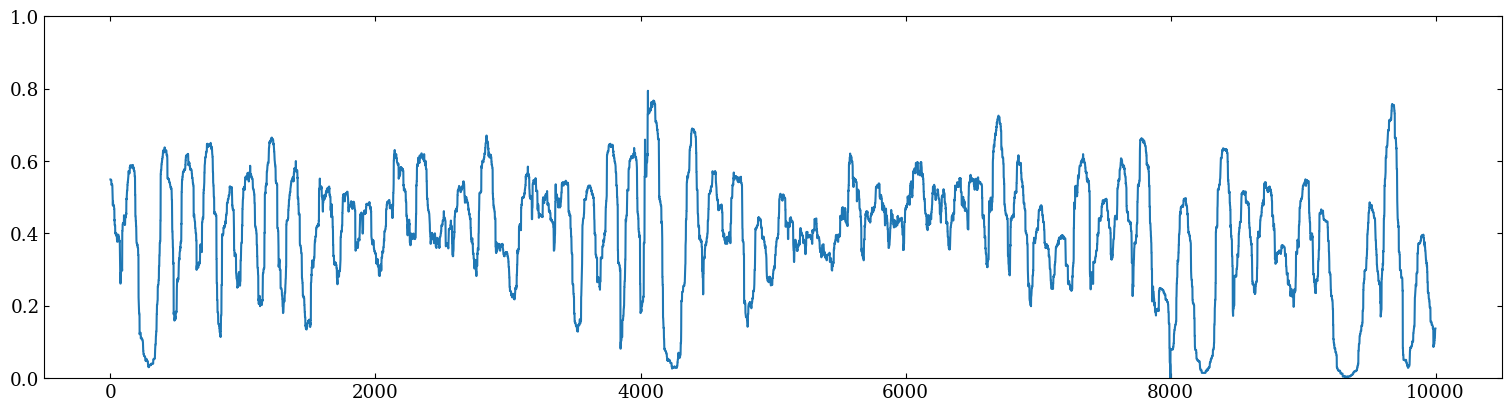

In [31]:
y= np.load("/home/mvenrooij/NucTool/nuctool/full_methylation_data_10000bp_interval_meth_filtered/chrII/occupancy_chrII.npy")

start, length = 92000, 10000
plotter.new(fig_size=(15,4))
ax = plotter.axes
ax.plot(y[start:start+length])
ax.set_ylim(0,1)
